# ETF Case Study: Feasibility Analysis

This notebook tests whether the ETF dataset can deliver on the strategy declared
in `config/setup.yaml`. `setup.yaml` is the canonical, hand-curated source of
truth: universe, costs, decision schedule, mapping class, labels, sweep grid,
and evaluation protocol. This notebook does not write it. Instead, it produces
the evidence that justifies its values: universe breadth over time, point-in-
time eligibility, return distributions at multiple horizons relative to
transaction costs, a walk-forward fold demonstration, and an edge-to-cost
ratio. Findings persist to `config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify the data delivers what `setup.yaml` assumes (breadth, costs, holdout)
- Implement point-in-time eligibility (no survivorship bias within the universe)
- Test whether typical price moves exceed transaction costs at candidate horizons
- Demonstrate the walk-forward structure has adequate breadth per fold
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2-6.6

## Prerequisites

- ETF data available via `load_etfs()`
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of walk-forward cross-validation (Section 6.5)

In [1]:
"""ETF Case Study: Feasibility Analysis."""

import json
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml

from data import load_etfs
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
CASE_STUDY_ID = "etfs"
START_DATE = "2006-01-01"
ADV_THRESHOLD = 10e6
MAX_SYMBOLS = 0

## Configuration

In [3]:
CASE_DIR = get_case_study_dir("etfs")
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
START_DATE = "2006-01-01"
END_DATE = "2025-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])


def as_float(value: object) -> float:
    """Convert Polars scalar outputs to plain float."""
    return float(str(value))

---

## Section A: Orientation (Section 6.2)

ETFs provide diversified exposure across asset classes with high liquidity and
low costs. This case study explores price-based signals at monthly cadences,
where turnover economics are manageable.

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Is point-in-time breadth adequate across the sample period?
- **Costs**: Do typical moves exceed the cost grid at candidate horizons?
- **Evaluation**: Do walk-forward folds carry enough cross-sectional breadth?
- **Holdout**: Is the holdout cleanly separated from training data?

---

## Section B: Universe and Cost Feasibility (Sections 6.3-6.4)

### B.1 Load and Explore the Data

In [4]:
etf_data = load_etfs()

start_dt = pl.Series([START_DATE]).str.to_date("%Y-%m-%d").item()
end_dt = pl.Series([END_DATE]).str.to_date("%Y-%m-%d").item()

prices = (
    etf_data.filter(pl.col("timestamp").is_between(start_dt, end_dt))
    .select(["symbol", "timestamp", "close", "volume"])
    .sort(["symbol", "timestamp"])
)

n_symbols = prices["symbol"].n_unique()
print(f"Loaded {n_symbols} ETFs, {len(prices):,} rows")
print(f"Period: {prices['timestamp'].min()} to {prices['timestamp'].max()}")

Loaded 100 ETFs, 470,662 rows
Period: 2006-01-03 to 2025-12-31


**Note**: The `close` column from `load_etfs()` is adjusted for splits and
dividends. We verify this by checking SPY's 2006 price level.

In [5]:
spy_2006 = prices.filter((pl.col("symbol") == "SPY") & (pl.col("timestamp").dt.year() == 2006))
spy_first_close = as_float(spy_2006["close"].first())
assert spy_first_close < 130, (
    f"SPY 2006 close={spy_first_close:.2f} looks unadjusted (expected ~$90-100 adjusted)"
)
print(f"SPY 2006 first close: ${spy_first_close:.2f} (adjusted -- verified)")

SPY 2006 first close: $87.23 (adjusted -- verified)


### B.2 Universe Selection: Rolling Point-in-Time Methodology

A critical mistake in backtesting is using **end-of-sample information** to select
the universe. For example, filtering to "ETFs with ADV > $50M" using today's volume
excludes ETFs that had sufficient volume historically but have since declined.

The correct approach is **rolling selection**: at each decision point, use only
information available at that time.

For this case study, we will:
1. First explore the historical distribution of dollar volume
2. Set a threshold that is realistic but lenient (this is a demo, not production)
3. Implement point-in-time universe membership

#### Exploratory Analysis: Dollar Volume Distribution Over Time

Before setting thresholds, we need to understand how dollar volume has evolved.
A threshold that seems reasonable today may have excluded most ETFs in 2007.

In [6]:
# Compute daily dollar volume
prices_with_dv = prices.with_columns((pl.col("close") * pl.col("volume")).alias("dollar_volume"))

# Annual statistics: median dollar volume across all ETF-days in each year
annual_dv_stats = (
    prices_with_dv.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(
        pl.col("dollar_volume").median().alias("median_dv"),
        pl.col("dollar_volume").quantile(0.25).alias("p25_dv"),
        pl.col("dollar_volume").quantile(0.75).alias("p75_dv"),
        pl.col("dollar_volume").quantile(0.90).alias("p90_dv"),
        pl.col("symbol").n_unique().alias("n_etfs"),
    )
    .sort("year")
)

# Display as DataFrame (values in millions)
annual_dv_stats.select(
    [
        "year",
        (pl.col("median_dv") / 1e6).round(1).alias("median_$M"),
        (pl.col("p75_dv") / 1e6).round(1).alias("p75_$M"),
        (pl.col("p90_dv") / 1e6).round(1).alias("p90_$M"),
        "n_etfs",
    ]
)

year,median_$M,p75_$M,p90_$M,n_etfs
i32,f64,f64,f64,u32
2006,14.5,70.2,445.3,71
2007,23.0,119.5,627.6,82
2008,43.2,174.1,984.3,85
2009,46.0,170.2,722.1,86
2010,53.0,233.2,679.4,87
…,…,…,…,…
2021,253.1,626.7,1327.6,100
2022,313.0,742.3,1613.2,100
2023,257.2,634.4,1283.1,100


#### Visualize the Dollar Volume Evolution

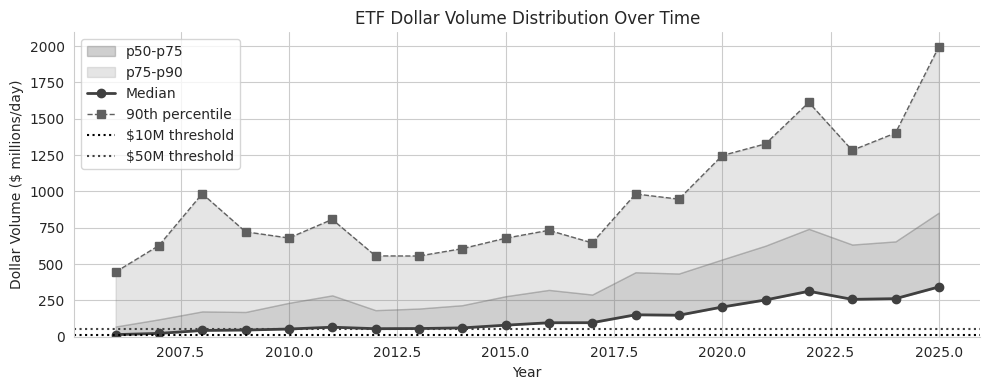

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

years = annual_dv_stats["year"].to_numpy()
median_dv = annual_dv_stats["median_dv"].to_numpy() / 1e6
p75_dv = annual_dv_stats["p75_dv"].to_numpy() / 1e6
p90_dv = annual_dv_stats["p90_dv"].to_numpy() / 1e6

ax.fill_between(years, median_dv, p75_dv, alpha=0.3, color="#606060", label="p50-p75")
ax.fill_between(years, p75_dv, p90_dv, alpha=0.2, color="#808080", label="p75-p90")
ax.plot(years, median_dv, "o-", color="#404040", linewidth=2, label="Median")
ax.plot(years, p90_dv, "s--", color="#606060", linewidth=1, label="90th percentile")

# Show potential thresholds
ax.axhline(10, color="black", linestyle=":", linewidth=1.5, label="$10M threshold")
ax.axhline(50, color="#404040", linestyle=":", linewidth=1.5, label="$50M threshold")

ax.set_xlabel("Year")
ax.set_ylabel("Dollar Volume ($ millions/day)")
ax.set_title("ETF Dollar Volume Distribution Over Time")
ax.legend(loc="upper left")
ax.set_ylim(0, None)
sns.despine()

fig.tight_layout()
plt.show()

#### Interpretation

The figure shows that:
- Dollar volume has grown substantially over time (market growth + ETF adoption)
- A \$50M/day threshold would have excluded many ETFs in early years
- A \$10M/day threshold is more inclusive historically

**For this demo case study**, we use a lenient threshold ($10M) to maintain a
broad universe (the sample of 100 ETFs has already been selected based on liquidity). A production system might use higher thresholds but would need
to account for the changing market structure.

#### Implement Rolling Universe Selection

The proper point-in-time approach: at the end of each year, compute trailing ADV
and select ETFs for the following year.

In [8]:
# For each ETF, compute trailing 252-day ADV at each month-end
# Then apply threshold to create point-in-time universe membership

# Simplification for demo: compute annual ADV and apply to next year.
# Note: annual granularity is coarser than the monthly decision cadence.
# An ETF that becomes illiquid in March remains "eligible" through December.
# Production systems would recompute eligibility at each decision date using
# a trailing window (e.g., 63-day or 126-day rolling ADV).
annual_adv = (
    prices_with_dv.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by(["symbol", "year"])
    .agg(
        pl.col("dollar_volume").mean().alias("avg_dv"),
        pl.col("timestamp").count().alias("n_days"),
    )
    .filter(pl.col("n_days") >= 200)  # Require most of the year
    .sort(["symbol", "year"])
)

# Threshold: $10M/day average (lenient for demo)
ADV_THRESHOLD = 10e6

eligible_by_year = (
    annual_adv.filter(pl.col("avg_dv") >= ADV_THRESHOLD)
    .with_columns((pl.col("year") + 1).alias("eligible_year"))
    .select(["symbol", "eligible_year", "avg_dv"])
)

# Count eligible ETFs per year
eligibility_counts = (
    eligible_by_year.group_by("eligible_year")
    .agg(pl.col("symbol").n_unique().alias("n_eligible"))
    .sort("eligible_year")
)

print(f"Eligible ETFs per year (ADV threshold: ${ADV_THRESHOLD / 1e6:.0f}M):")
eligibility_counts

Eligible ETFs per year (ADV threshold: $10M):


eligible_year,n_eligible
i32,u32
2007,43
2008,53
2009,67
2010,67
2011,75
…,…
2022,95
2023,96
2024,93


#### Point-in-Time Universe: Eligibility Mask

**Critical**: We do NOT filter to a fixed asset list based on full-sample eligibility.
That would use future information (survivorship bias). Instead, we create a
point-in-time eligibility table that downstream code uses at each decision date.

The rule: an ETF is tradable in year Y if it met the ADV threshold in year Y-1.

**Two-Layer Bias Assessment**:

Understanding survivorship bias in this case study requires distinguishing two layers:

- **Layer 1 (universe composition)**: The 100 ETFs were selected *after the fact*
  based on their relevance and liquidity at sample end (2025). ETFs that were liquid
  in 2007 but have since been delisted or merged are excluded. This bias **cannot be
  fully resolved** without historical constituent data, which is not readily available
  for ETFs. It inflates apparent signal quality by removing negative outcomes.

- **Layer 2 (eligibility within the universe)**: Given the 100-ETF sample, the
  point-in-time ADV filter correctly prevents using future liquidity information.
  An ETF is only tradable in year Y if it met the threshold in year Y-1. This layer
  **is** point-in-time correct.

The two layers partially work at cross purposes: the rolling filter creates rigor at
Layer 2 while Layer 1 already embeds the bias it's trying to avoid. Readers should
understand which bias is mitigated (within-universe eligibility) and which is not
(universe composition).

Additionally, the $10M ADV threshold is not inflation-adjusted. Ten million
dollars in 2006 had different purchasing power than in 2025. A more rigorous
approach would step down the threshold for earlier years (e.g., scale by CPI
or market cap growth). We proceed with the fixed threshold for simplicity---the
100-ETF universe was already curated for liquidity.

In [9]:
# All assets in the dataset are candidates
ASSETS = prices["symbol"].unique().sort().to_list()

# Eligibility table: which assets are tradable in which years
# eligibility_by_year already has (asset, eligible_year) pairs
eligibility_table = eligible_by_year.select(["symbol", "eligible_year"]).unique()

# Summary: how many ETFs eligible per year
eligibility_summary = (
    eligibility_table.group_by("eligible_year")
    .agg(pl.col("symbol").count().alias("n_eligible"))
    .sort("eligible_year")
)

print(f"\nCandidate universe: {len(ASSETS)} ETFs (all assets in dataset)")
print("Point-in-time eligibility determined annually based on prior-year ADV")
print("\nEligible ETFs by year:")
eligibility_summary


Candidate universe: 100 ETFs (all assets in dataset)
Point-in-time eligibility determined annually based on prior-year ADV

Eligible ETFs by year:


eligible_year,n_eligible
i32,u32
2007,43
2008,53
2009,67
2010,67
2011,75
…,…
2022,95
2023,96
2024,93


---

### B.3 Trading Cost Analysis: Horizon Feasibility

A fundamental question for any trading strategy is: **at which holding periods
do typical price moves exceed transaction costs?**

This analysis informs which horizons are worth exploring, without prescribing
a specific signal type.

#### Return Distributions at Multiple Horizons

We compute returns at daily, weekly, and monthly frequencies and examine their
distributions relative to transaction costs.

In [10]:
# Filter to universe assets
universe_prices = prices.filter(pl.col("symbol").is_in(ASSETS)).sort(["symbol", "timestamp"])

# Daily returns
daily_returns = (
    universe_prices.with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
    )
    .filter(pl.col("return").is_not_null())
    .select(["symbol", "timestamp", "return"])
)

# Weekly returns (resample to week-end)
weekly_prices = (
    universe_prices.with_columns(pl.col("timestamp").dt.strftime("%G-W%V").alias("week"))
    .group_by(["symbol", "week"])
    .agg(pl.col("close").last().alias("close"), pl.col("timestamp").max().alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
weekly_returns = weekly_prices.with_columns(
    (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
).filter(pl.col("return").is_not_null())

# Monthly returns
monthly_prices = (
    universe_prices.with_columns(pl.col("timestamp").dt.strftime("%Y-%m").alias("month"))
    .group_by(["symbol", "month"])
    .agg(pl.col("close").last().alias("close"), pl.col("timestamp").max().alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
monthly_returns = monthly_prices.with_columns(
    (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
).filter(pl.col("return").is_not_null())

print(f"Daily returns: {len(daily_returns):,} observations")
print(f"Weekly returns: {len(weekly_returns):,} observations")
print(f"Monthly returns: {len(monthly_returns):,} observations")

Daily returns: 470,562 observations
Weekly returns: 97,586 observations
Monthly returns: 22,369 observations


#### Summary Statistics by Horizon

The key question: what fraction of absolute price moves exceed the round-trip cost?

In [11]:
# Extract absolute returns
daily_abs = daily_returns["return"].abs().to_numpy()
weekly_abs = weekly_returns["return"].abs().to_numpy()
monthly_abs = monthly_returns["return"].abs().to_numpy()

# Cost assumptions: per-leg cost 10 bps → round-trip 20 bps
PER_LEG_COST_BPS = 10
ROUND_TRIP_COST_BPS = 2 * PER_LEG_COST_BPS
ROUND_TRIP_COST = ROUND_TRIP_COST_BPS / 10_000  # 0.0020


# Build summary DataFrame
def compute_return_stats(data: np.ndarray, horizon: str) -> dict:
    """Compute return distribution statistics for a given horizon."""
    return {
        "horizon": horizon,
        "median_pct": np.median(data) * 100,
        "mean_pct": np.mean(data) * 100,
        "std_pct": np.std(data) * 100,
        "p75_pct": np.percentile(data, 75) * 100,
        "p95_pct": np.percentile(data, 95) * 100,
        "pct_above_20bps": (data > ROUND_TRIP_COST).mean() * 100,
    }


return_stats = pl.DataFrame(
    [
        compute_return_stats(daily_abs, "Daily"),
        compute_return_stats(weekly_abs, "Weekly"),
        compute_return_stats(monthly_abs, "Monthly"),
    ]
)

**Return Distribution Summary** (absolute returns):

In [12]:
return_stats.select(
    [
        "horizon",
        pl.col("median_pct").round(2).alias("median %"),
        pl.col("mean_pct").round(2).alias("mean %"),
        pl.col("std_pct").round(2).alias("std %"),
        pl.col("p75_pct").round(2).alias("p75 %"),
        pl.col("p95_pct").round(2).alias("p95 %"),
    ]
)

horizon,median %,mean %,std %,p75 %,p95 %
str,f64,f64,f64,f64,f64
"""Daily""",0.56,0.91,1.14,1.19,2.91
"""Weekly""",1.3,1.99,2.27,2.67,6.11
"""Monthly""",2.85,4.02,4.13,5.53,11.78


**Fraction of moves exceeding cost threshold** (round-trip = 20 bps):

In [13]:
# Cost threshold analysis
COST_THRESHOLDS_BPS = [10, 20, 30, 50]

cost_exceedance = []
for horizon, data in [("Daily", daily_abs), ("Weekly", weekly_abs), ("Monthly", monthly_abs)]:
    row = {"horizon": horizon}
    for cost_bps in COST_THRESHOLDS_BPS:
        row[f"{cost_bps}_bps"] = (data > cost_bps / 10_000).mean() * 100
    cost_exceedance.append(row)

cost_df = pl.DataFrame(cost_exceedance)
cost_df.select(
    [
        "horizon",
        pl.col("10_bps").round(1).alias("10 bps %"),
        pl.col("20_bps").round(1).alias("20 bps %"),
        pl.col("30_bps").round(1).alias("30 bps %"),
        pl.col("50_bps").round(1).alias("50 bps %"),
    ]
)

horizon,10 bps %,20 bps %,30 bps %,50 bps %
str,f64,f64,f64,f64
"""Daily""",86.7,76.6,67.8,53.7
"""Weekly""",93.7,88.6,84.0,75.4
"""Monthly""",96.9,94.3,92.1,87.7


#### Visualize Return Distributions

The visualization shows return distributions at each horizon with cost reference lines.
Note how the distributions widen as the horizon increases.

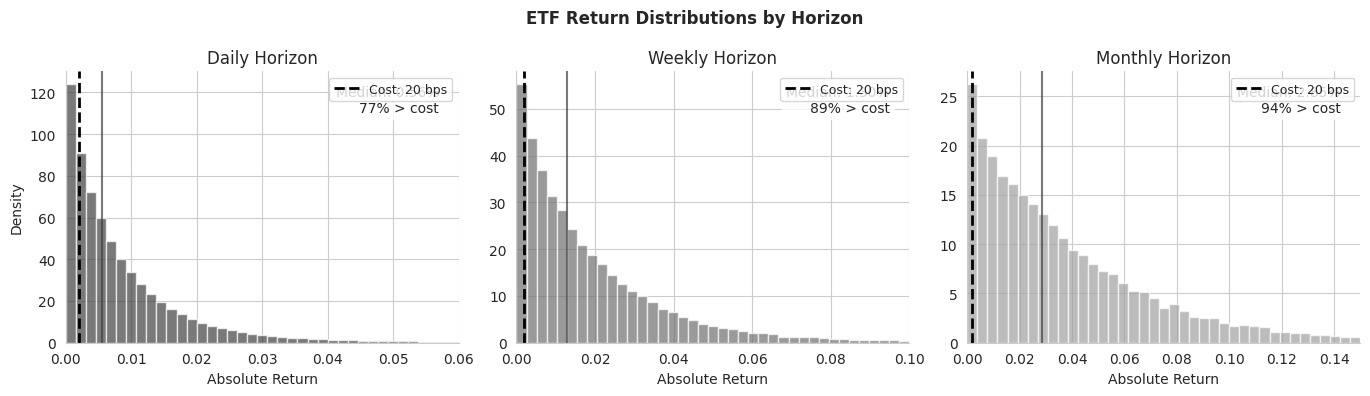

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Use grayscale for book compatibility
horizons = [
    ("Daily", daily_abs, "#404040"),
    ("Weekly", weekly_abs, "#707070"),
    ("Monthly", monthly_abs, "#a0a0a0"),
]

for ax, (label, data, color) in zip(axes, horizons, strict=False):
    # Use different x-limits to show the actual distribution shape
    if label == "Daily":
        xlim = 0.06
    elif label == "Weekly":
        xlim = 0.10
    else:
        xlim = 0.15

    # Histogram
    bins = np.linspace(0, xlim, 40)
    ax.hist(data[data < xlim], bins=bins, density=True, alpha=0.7, color=color, edgecolor="white")

    # Cost reference line
    ax.axvline(ROUND_TRIP_COST, color="black", linestyle="--", linewidth=2, label="Cost: 20 bps")

    # Statistics annotation
    median_val = np.median(data)
    frac_above = (data > ROUND_TRIP_COST).mean()
    ax.axvline(median_val, color="#404040", linestyle="-", linewidth=1.5, alpha=0.7)

    stats_text = f"Median: {median_val * 100:.2f}%\n{frac_above:.0%} > cost"
    ax.text(
        0.95,
        0.95,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_xlabel("Absolute Return")
    ax.set_title(f"{label} Horizon")
    ax.set_xlim(0, xlim)
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Density")
fig.suptitle("ETF Return Distributions by Horizon", fontsize=12, fontweight="bold")
sns.despine()
fig.tight_layout()
plt.show()

#### Interpretation

The return distributions clearly differ by horizon. Looking at the tables above:

- **Daily**: Median moves are small relative to costs. A majority of moves exceed
  the 20 bps threshold, but high-turnover strategies operate with thin margins.
- **Weekly**: Moves are larger, providing reasonable headroom over costs.
- **Monthly**: Moves comfortably exceed costs in the vast majority of cases.

**Connecting costs to the cost model**: The cost exceedance table above spans
10 to 50 bps round-trip. Our stated cost model (5--15 bps per leg, i.e., 10--30
bps round-trip) maps directly to the 10, 20, and 30 bps columns. For large liquid
ETFs (SPY, QQQ) at the low end (10 bps RT), even daily moves exceed costs ~75%
of the time. For smaller thematic ETFs at the high end (30 bps RT), only monthly
moves are comfortably above cost in most observations. The choice of horizon
therefore depends on the *cost tier* of the ETFs you're trading, not just the
horizon in isolation.

**This analysis guides but does not dictate**: We establish that all three horizons
are feasible. Chapter 7 will test features at each horizon.

#### Cost-Regime Choice: per-Share + Tiered Spread

`setup.yaml::costs.model = per_share_plus_spread` — costs are declared as
a per-share commission plus a per-asset half-spread in dollars per share,
not as a flat bps rate.

**Commission.** The `per_share = 0.0035` value is IBKR Pro Tiered's top
tier (the rate readers see at the broker when they execute monthly ETF
rotations at retail scale). This is the library default in
`ml4t-backtest` set because we downloaded IBKR Pro pricing for exactly
this purpose — the cost dispatcher has nothing to invent.

**Spread.** The per-asset half-spread map in
`setup.yaml::costs.asset_spreads` ties each ticker to an industry-
knowledge tier: mega-ETFs (SPY/QQQ/IWM/EFA/EEM/DIA/VTI/VOO) at 0.5¢,
sector XL* funds at 1¢, default 2¢ for thematic/regional/factor ETFs.
This is a *reasoned simplification* — ETF nominal prices do not drift
much over the validation window, so a static map is defensible — but it
is **not** an empirical measurement. We do not have AlgoSeek-grade NBBO
quotes spanning the broad ETF universe; the analogous case study with
measured per-asset spreads is `nasdaq100_microstructure`, which has
AlgoSeek minute-bar NBBO close quotes for its 100-ticker NASDAQ-100
universe. The nasdaq100 measurements are NOT a proxy for liquid-ETF
spreads: they cover different securities under different microstructure.
The tiered ETF map should be read as "what an institutional trader
knowledgeable about US ETFs would assert as the going rate" rather than
as a quote-grounded estimate. The cost sensitivity sweep in `16_costs.py`
probes how robust this assumption is across both bps and per-share
grids.

### B.4 Feasibility Ratio

A simple edge-to-cost ratio confirms that typical signal magnitude
comfortably exceeds transaction costs before proceeding further.

In [15]:
median_monthly_abs_return = float(np.median(monthly_abs))
feasibility_ratio = median_monthly_abs_return / ROUND_TRIP_COST
print(
    f"Median monthly |return|: {median_monthly_abs_return:.4f} ({median_monthly_abs_return * 10000:.1f} bps)"
)
print(f"Round-trip cost: {ROUND_TRIP_COST:.4f} ({ROUND_TRIP_COST * 10000:.0f} bps)")
print(f"Edge-to-cost ratio: {feasibility_ratio:.1f}x")
print(f"Assessment: {'PROCEED' if feasibility_ratio > 1.0 else 'KILL -- edge too thin'}")

Median monthly |return|: 0.0285 (284.6 bps)
Round-trip cost: 0.0020 (20 bps)
Edge-to-cost ratio: 14.2x
Assessment: PROCEED


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml` that the
feasibility evidence above supports. They are justified here, not in the YAML.

### C.1 Decision Cadence

Monthly month-end is the conventional cadence for cross-asset momentum studies
(Moskowitz, Ooi, and Pedersen 2012; Asness, Moskowitz, and Pedersen 2013), which
makes our results directly comparable to published benchmarks. However, the choice
deserves scrutiny rather than deference.

A **weekly (5-day) cadence** would multiply effective sample size roughly 4x
(~1,040 weekly vs ~240 monthly decision dates), improving IC estimate stability
per fold. Purging becomes cheaper: a 1-week purge burns 5 trading days vs 21 for
monthly. The cost analysis above confirms that weekly absolute returns comfortably
exceed the 20 bps round-trip threshold for most of the universe.

The complications are real: turnover increases mechanically (even if signals are
slow-moving, weekly rebalancing amplifies noise-driven rank changes), and coupling
signal horizon with decision cadence requires care---you can evaluate a signal weekly
but still use 4-week forward labels, at the cost of overlapping labels that demand
proper purge/embargo handling.

We treat cadence as a **first-class parameter**. `setup.yaml` declares the
default monthly cadence (`decision.cadence: monthly_month_end`) and exposes
`fwd_ret_5d` as a weekly-horizon label variant for comparison.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints --- if any triggers, the strategy
is abandoned or substantially reworked. Defining them upfront prevents
post-hoc rationalization. The thresholds below are anchored to the feasibility
evidence above (cost-exceedance and edge-to-cost analysis):

- **KC1 (IC floor)**: IC < 0.01 with t-stat < 2.0 across all lookback horizons
  (3M-12M). Gate: Chapter 8 feature evaluation.
- **KC2 (edge-cost)**: Edge-to-cost ratio < 1.0x after realistic transaction
  costs. Gate: Chapter 7 label evaluation / Chapter 16 backtest. B.4 above
  tests this gate on raw return magnitudes before the model is even trained.
- **KC3 (EW underperformance)**: Equal-weight benchmark posts a higher Sharpe
  and lower max drawdown than the strategy across all test folds. Gate:
  Chapter 16 backtest.

### C.3 Mapping Class

`setup.yaml` declares the simplest credible mapping: **long-only, equal-weight,
top-N** (`mapping.class: long_only_rank_and_rebalance`, `sizing: equal_weight`).
Long-only is appropriate because (a) most ETFs are difficult or expensive to
short, (b) the target audience for this case study is long-only portfolio
construction, and (c) it isolates the ranking signal from short-side
complexity. Equal-weight is the minimal-assumption sizing rule---it avoids
introducing a secondary optimization (risk-parity, inverse-vol) that would
confound evaluation of the ranking signal itself. Chapter 17 explores
alternative weighting schemes via the `backtest.sweep.allocators` grid in
`setup.yaml`.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify that the data supports the walk-forward design declared in
`setup.yaml::evaluation` (`n_splits`, `train_size`, `val_size`, `holdout_start`).

### D.1 Effective Sample Size and Data Coverage

In [16]:
n_decision_dates = monthly_prices["month"].n_unique()
first_month = monthly_prices["month"].min()
last_month = monthly_prices["month"].max()
n_years = n_decision_dates / 12

print("Data Coverage:")
print(f"  Period: {first_month} to {last_month}")
print(f"  Decision points (months): {n_decision_dates}")
print(f"  Approx years: {n_years:.1f}")

Data Coverage:
  Period: 2006-01 to 2025-12
  Decision points (months): 240
  Approx years: 20.0


### D.2 Walk-Forward Fold Demonstration

`case_studies/utils/cv_window.py` owns the operational splits; this cell
reproduces the fold boundaries from canonical `setup.yaml` parameters to verify
the data supports the declared design. Each fold has:

- **Train period**: `setup.yaml::evaluation.train_size`
- **Test period**: `setup.yaml::evaluation.val_size`
- **Purge gap**: 1 month between train end and test start (matches the 21D
  buffer for the 1-month primary label)

In [17]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
purge_months = 1  # matches setup.yaml::labels.buffer (21D) at monthly cadence
train_months = 10 * 12  # setup.yaml::evaluation.train_size = 10Y
test_months = 1 * 12  # setup.yaml::evaluation.val_size = 1Y
step_months = 1 * 12  # consecutive, non-overlapping

# Get sorted list of decision dates (month-ends)
decision_dates = (
    monthly_prices.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
)

# Holdout boundary
holdout_start_dt = pl.Series([HOLDOUT_START]).str.to_date("%Y-%m-%d").item()
cv_dates = [d for d in decision_dates if d < holdout_start_dt]

# Generate splits
splits = []
test_start_idx = train_months

while test_start_idx + test_months <= len(cv_dates):
    train_start_idx = test_start_idx - train_months
    train_end_idx = test_start_idx - purge_months  # purge gap
    test_end_idx = test_start_idx + test_months

    split = {
        "fold": len(splits) + 1,
        "train_start": cv_dates[train_start_idx].strftime("%Y-%m-%d"),
        "train_end": cv_dates[train_end_idx - 1].strftime("%Y-%m-%d"),
        "test_start": cv_dates[test_start_idx].strftime("%Y-%m-%d"),
        "test_end": cv_dates[test_end_idx - 1].strftime("%Y-%m-%d"),
        "purge_months": purge_months,
    }
    splits.append(split)
    test_start_idx += step_months

print(f"Generated {len(splits)} walk-forward folds")

# Sanity check: verify all folds fit within pre-holdout data
assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
last_test_end = splits[-1]["test_end"]
print(f"Last fold test end: {last_test_end}  |  Holdout start: {HOLDOUT_START}")
assert last_test_end < HOLDOUT_START, (
    f"Last fold ({last_test_end}) overlaps holdout ({HOLDOUT_START})"
)

Generated 8 walk-forward folds
Last fold test end: 2023-12-29  |  Holdout start: 2024-01-01


**Walk-forward fold summary:**

In [18]:
splits_df = pl.DataFrame(splits)
splits_df

fold,train_start,train_end,test_start,test_end,purge_months
i64,str,str,str,str,i64
1,"""2006-01-31""","""2015-11-30""","""2016-01-29""","""2016-12-30""",1
2,"""2007-01-31""","""2016-11-30""","""2017-01-31""","""2017-12-29""",1
3,"""2008-01-31""","""2017-11-30""","""2018-01-31""","""2018-12-31""",1
4,"""2009-01-30""","""2018-11-30""","""2019-01-31""","""2019-12-31""",1
5,"""2010-01-29""","""2019-11-29""","""2020-01-31""","""2020-12-31""",1
6,"""2011-01-31""","""2020-11-30""","""2021-01-29""","""2021-12-31""",1
7,"""2012-01-31""","""2021-11-30""","""2022-01-31""","""2022-12-30""",1
8,"""2013-01-31""","""2022-11-30""","""2023-01-31""","""2023-12-29""",1


#### Universe Breadth per Fold

We verify that each fold has adequate cross-sectional breadth by counting
eligible ETFs in each test period. Thin early folds would weaken cross-sectional
signals (quintile sorting requires reasonable N).

In [19]:
fold_breadth = []
for split in splits:
    test_year = int(split["test_start"][:4])
    n_eligible = eligibility_table.filter(pl.col("eligible_year") == test_year).height
    fold_breadth.append(
        {
            "fold": split["fold"],
            "test_year": test_year,
            "n_eligible": n_eligible,
        }
    )

fold_breadth_df = pl.DataFrame(fold_breadth)
print("Eligible ETFs per fold test period:")
fold_breadth_df

Eligible ETFs per fold test period:


fold,test_year,n_eligible
i64,i64,i64
1,2016,88
2,2017,94
3,2018,96
4,2019,96
5,2020,95
6,2021,95
7,2022,95
8,2023,96


All folds have 70+ eligible ETFs, which is sufficient for cross-sectional ranking
and quintile construction. The early folds have fewer ETFs because some symbols
(e.g., ARKK, XLC) had not yet launched---this is the correct point-in-time behavior,
not a data problem.

---

## Section E: Eligibility Artifact

Point-in-time (asset, year) eligibility is the one decision-relevant artifact
this notebook generates (everything else lives in `setup.yaml`). It is keyed by
year because the ADV filter runs annually; downstream labels and features
consume it to enforce point-in-time membership.

In [20]:
eligibility_path = CASE_DIR / "eligibility.csv"
eligibility_table.select(["symbol", "eligible_year"]).sort(["symbol", "eligible_year"]).write_csv(
    eligibility_path
)
print(f"Written: {eligibility_path} ({len(eligibility_table):,} asset-year pairs)")

Written: case_studies/etfs/eligibility.csv (1,670 asset-year pairs)


---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. Setup.yaml is not regenerated here --- it is the hand-curated
source of truth, and this notebook reads it.

In [21]:
# Numbers used in the side-by-side report
median_d_abs_pct = float(np.median(daily_abs) * 100)
median_w_abs_pct = float(np.median(weekly_abs) * 100)
median_m_abs_pct = float(np.median(monthly_abs) * 100)
frac_d_above_20 = float((daily_abs > 0.0020).mean())
frac_w_above_20 = float((weekly_abs > 0.0020).mean())
frac_m_above_20 = float((monthly_abs > 0.0020).mean())
n_eligible_min = int(min(fb["n_eligible"] for fb in fold_breadth))
n_eligible_max = int(max(fb["n_eligible"] for fb in fold_breadth))
n_folds_generated = int(len(splits))

print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.n_assets = {SETUP['universe']['n_assets']}")
print(f"  -> point-in-time eligible per fold: min={n_eligible_min}, max={n_eligible_max}")
print("  -> sufficient for cross-sectional ranking (>=70 per fold)")

print()
print(f"decision.cadence = {SETUP['decision']['cadence']}")
print(
    f"  -> median |monthly return| = {median_m_abs_pct:.2f}%; "
    f"{frac_m_above_20 * 100:.0f}% exceed 20bps RT"
)

print()
print(f"costs.model = {SETUP['costs']['model']}")
print(f"  -> at 20bps RT: edge-to-cost = {feasibility_ratio:.0f}x at monthly horizon")
print(f"  -> daily moves > 20bps: {frac_d_above_20 * 100:.0f}%")
print(f"  -> weekly moves > 20bps: {frac_w_above_20 * 100:.0f}%")

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(
    f"  -> median |21d return| = {median_m_abs_pct:.2f}% = "
    f"{(median_m_abs_pct / 100) / 0.002:.0f}x a 20bps cost"
)

print()
print(f"labels.variants = {SETUP['labels']['variants']}")
print(
    f"  -> median |weekly return| = {median_w_abs_pct:.2f}% ({frac_w_above_20 * 100:.0f}% > 20bps)"
)

print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"  -> generated {n_folds_generated} folds; declared count matches")
print(
    f"  -> holdout {SETUP['evaluation']['holdout_start']} "
    f"to {SETUP['evaluation']['holdout_end']}; "
    f"last test ends {splits[-1]['test_end']}"
)

Setup.yaml knobs vs feasibility evidence

universe.n_assets = 100
  -> point-in-time eligible per fold: min=88, max=96
  -> sufficient for cross-sectional ranking (>=70 per fold)

decision.cadence = monthly_month_end
  -> median |monthly return| = 2.85%; 94% exceed 20bps RT

costs.model = per_share_plus_spread
  -> at 20bps RT: edge-to-cost = 14x at monthly horizon
  -> daily moves > 20bps: 77%
  -> weekly moves > 20bps: 89%

labels.primary = fwd_ret_21d
  -> median |21d return| = 2.85% = 14x a 20bps cost

labels.variants = ['fwd_ret_5d']
  -> median |weekly return| = 1.30% (89% > 20bps)

evaluation.n_splits = 8
  -> generated 8 folds; declared count matches
  -> holdout 2024-01-01 to 2025-12-31; last test ends 2023-12-29


### Persist Feasibility Findings

In [22]:
feasibility_report = {
    "case_study_id": "etfs",
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE},
    "universe": {
        "n_assets_declared": int(SETUP["universe"]["n_assets"]),
        "n_eligible_per_fold_min": n_eligible_min,
        "n_eligible_per_fold_max": n_eligible_max,
    },
    "return_distribution_abs_pct": {
        "daily_median": median_d_abs_pct,
        "weekly_median": median_w_abs_pct,
        "monthly_median": median_m_abs_pct,
    },
    "cost_exceedance_at_20bps_pct": {
        "daily": frac_d_above_20 * 100,
        "weekly": frac_w_above_20 * 100,
        "monthly": frac_m_above_20 * 100,
    },
    "feasibility_ratio_monthly_at_20bps": float(feasibility_ratio),
    "walk_forward": {
        "n_folds_generated": n_folds_generated,
        "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
        "holdout_start": HOLDOUT_START,
        "last_test_end": splits[-1]["test_end"],
    },
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2)
print(f"Written: {report_path}")

Written: case_studies/etfs/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Universe**: Two-layer bias assessment---universe composition has survivorship
   bias (Layer 1, not fully resolvable, the 100 ETFs were chosen backward-looking);
   within-universe eligibility is point-in-time correct (Layer 2, via $10M ADV
   threshold applied annually with one-year lag). 70+ eligible ETFs per fold.
2. **Cost feasibility**: All three horizons clear the 20bps round-trip threshold,
   but the margin depends on the cost tier---large liquid ETFs (10 bps RT) support
   daily strategies, while smaller thematic ETFs (30 bps RT) require monthly
   holding periods. `setup.yaml` accommodates both via tiered `costs.asset_spreads`.
3. **Cadence**: Monthly month-end as default for literature comparability;
   weekly tested as a variant via `labels.variants: [fwd_ret_5d]`.
4. **Mapping**: Long-only equal-weight top-N as simplest credible baseline;
   alternative allocators sweep in `setup.yaml::backtest.sweep.allocators`
   (explored in Chapter 17).
5. **Evaluation**: 8 walk-forward folds with verified holdout separation
   (`evaluation.holdout_start` enforced).
6. **Kill conditions**: KC2 (edge-to-cost > 1.0x) already cleared---feasibility
   ratio at monthly horizon is comfortably above 1.0 on raw return magnitudes.
   KC1 (IC floor) and KC3 (EW underperformance) are tested in later chapters.

**Known limitations**:
- Layer 1 survivorship bias is documented but not resolved.
- Annual eligibility granularity is coarser than monthly decision cadence.
- The $10M ADV threshold is not inflation-adjusted.

**Artifacts written**:
- `eligibility.csv`: point-in-time (asset, year) membership.
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running this notebook.

**Next**: Chapter 7 creates labels at the monthly and weekly horizons declared
in `setup.yaml::labels`.